## بسم الله الرحمن الرحیم

### بازرسی داده خام، بررسی کلاس‌ها، انتخاب LV، تقسیم بیمارمحور

# 01 | EDA و تقسیم‌بندی بیمارمحور

در این نوت‌بوک:
- ساختار دیتاست خام ACDC را بررسی می‌کنیم.
- مقادیر یکتای لیبل‌ها را **از روی داده واقعی** استخراج می‌کنیم.
- تصویر و لیبل یک نمونه را باز کرده و اطلاعات affine / shape را می‌بینیم.
- توزیع کلاس‌ها را برای `frame01` رسم می‌کنیم.
- داده‌ها را **بر اساس بیمار** (نه برش) به train / val / test تقسیم می‌کنیم.
- خروجی `splits.json` ذخیره می‌شود.

هیچ فایلی در `data/raw` تغییر نمی‌کند.

In [1]:
from pathlib import Path
import json
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# اگر از نوت‌بوک قبلی اجرا نکرده‌اید، مسیرها را تعریف کنید
CURRENT = Path.cwd()
PROJECT_ROOT = CURRENT.parent if CURRENT.name == "notebooks" else Path(r"C:\Users\MahdiCS313\Downloads\Proposal_Nazanin\ACDC-SAMMed3D")
RAW_DATA = PROJECT_ROOT / "data" / "ACDC" / "database"
OUTPUT_ROOT = PROJECT_ROOT.parent / "outputs"
OUTPUT_ROOT.mkdir(parents=True, exist_ok=True)

print("RAW_DATA:", RAW_DATA)
print("OUTPUT_ROOT:", OUTPUT_ROOT)

RAW_DATA: c:\Users\MahdiCS313\Downloads\Proposal_Nazanin\ACDC-SAMMed3D\data\ACDC\database
OUTPUT_ROOT: c:\Users\MahdiCS313\Downloads\Proposal_Nazanin\outputs


In [2]:
def list_cases(root: Path):
    """Return all image/label pairs from training and testing folders."""
    cases = []
    for split in ["training", "testing"]:
        split_dir = root / split
        if not split_dir.exists():
            continue
        for patient_dir in sorted(split_dir.iterdir()):
            if not patient_dir.is_dir() or not patient_dir.name.startswith("patient"):
                continue
            imgs = sorted(patient_dir.glob("*_frame*.nii"))
            lbls = sorted(patient_dir.glob("*_frame*_gt.nii"))
            for img_path, lbl_path in zip(imgs, lbls):
                cases.append({
                    "patient_id": patient_dir.name,
                    "case_id": img_path.name.replace(".nii", ""),
                    "image": img_path,
                    "label": lbl_path,
                })
    return cases

cases = list_cases(RAW_DATA)
print(f"Total cases found: {len(cases)}")

# تعداد بیمارها
patients = sorted({c["patient_id"] for c in cases})
print(f"Total patients: {len(patients)}")

# نمایش چند مورد
for c in cases[:5]:
    print(c["patient_id"], "->", c["image"].name, "|", c["label"].name)

Total cases found: 300
Total patients: 150
patient001 -> patient001_frame01.nii | patient001_frame01_gt.nii
patient001 -> patient001_frame01_gt.nii | patient001_frame12_gt.nii
patient002 -> patient002_frame01.nii | patient002_frame01_gt.nii
patient002 -> patient002_frame01_gt.nii | patient002_frame12_gt.nii
patient003 -> patient003_frame01.nii | patient003_frame01_gt.nii


In [3]:
# استخراج مقادیر یکتای لیبل از 15 بیمار اول
unique_values = set()
sample_shapes = {}

for case in cases[:15]:
    img = nib.load(case["image"])
    lbl = nib.load(case["label"])

    # shape
    sample_shapes[case["case_id"]] = (img.shape, lbl.shape)

    # unique labels
    data = lbl.get_fdata()
    unique_values.update(np.unique(data).astype(int).tolist())

print("Unique non-background label values found:", sorted(unique_values))
print("\nSample shapes:")
for k, v in list(sample_shapes.items())[:3]:
    print(f"  {k}: image shape={v[0]}, label shape={v[1]}")

Unique non-background label values found: [0, 1, 2, 3]

Sample shapes:
  patient001_frame01: image shape=(216, 256, 10), label shape=(216, 256, 10)
  patient001_frame01_gt: image shape=(216, 256, 10), label shape=(216, 256, 10)
  patient002_frame01: image shape=(232, 256, 10), label shape=(232, 256, 10)


In [4]:
# تفسیر استاندارد ACDC
standard_mapping = {1: "RV", 2: "MYO", 3: "LV"}

print("Interpretation for standard ACDC labels:")
for val in sorted(unique_values):
    if val == 0:
        print(f"  {val}: background")
    else:
        print(f"  {val}: {standard_mapping.get(val, 'unknown')}")

# برای پروژه، LV را انتخاب می‌کنیم
TARGET_LABEL_ID = 3
TARGET_CLASS_NAME = "LV"
print(f"\nSelected target: {TARGET_CLASS_NAME} (label_id={TARGET_LABEL_ID})")

Interpretation for standard ACDC labels:
  0: background
  1: RV
  2: MYO
  3: LV

Selected target: LV (label_id=3)


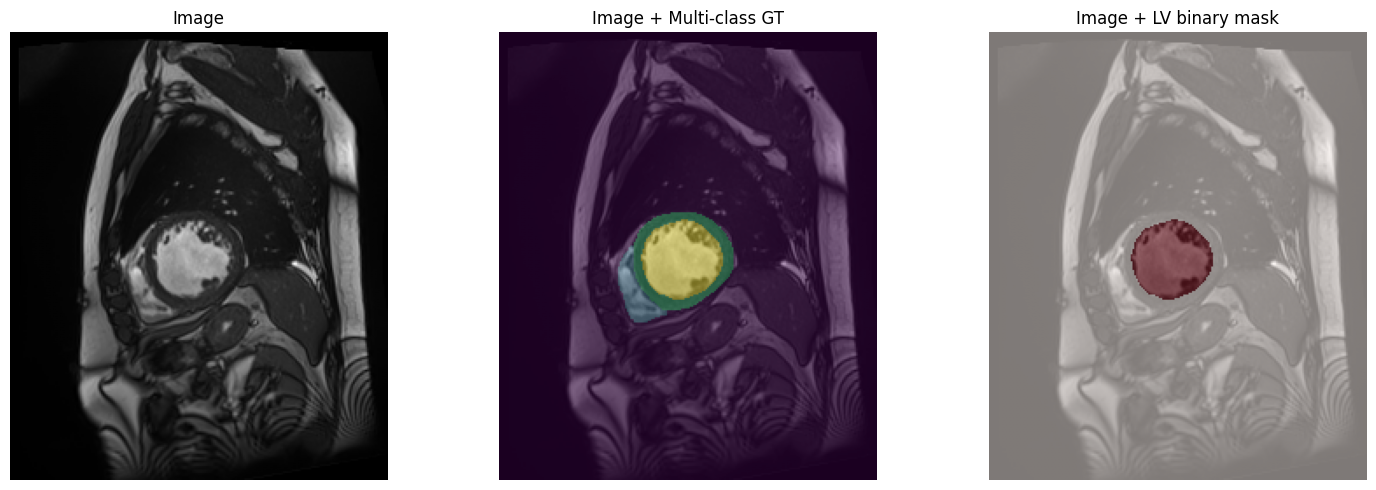

Affine of example image:
[[-1. -0.  0.  0.]
 [-0. -1.  0.  0.]
 [ 0.  0.  1.  0.]
 [ 0.  0.  0.  1.]]


In [5]:
# نمایش یک نمونه (وسط حجم در محور axial)
example = cases[0]
img_nib = nib.load(example["image"])
lbl_nib = nib.load(example["label"])

img_data = img_nib.get_fdata()
lbl_data = lbl_nib.get_fdata().astype(int)

mid_slice = img_data.shape[2] // 2
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(img_data[:, :, mid_slice].T, cmap="gray")
axes[0].set_title("Image")
axes[0].axis("off")

axes[1].imshow(img_data[:, :, mid_slice].T, cmap="gray")
axes[1].imshow(lbl_data[:, :, mid_slice].T, alpha=0.4)
axes[1].set_title("Image + Multi-class GT")
axes[1].axis("off")

lv_mask = (lbl_data[:, :, mid_slice] == TARGET_LABEL_ID)
axes[2].imshow(img_data[:, :, mid_slice].T, cmap="gray")
axes[2].imshow(lv_mask.T, alpha=0.5, cmap="Reds")
axes[2].set_title("Image + LV binary mask")
axes[2].axis("off")
plt.tight_layout()
plt.show()

print("Affine of example image:")
print(img_nib.affine)

In [6]:
# توزیع کلاس‌ها برای frame01 (مانند فایل CSV قبلی)
rows = []
for case in cases:
    if "frame01" in case["case_id"]:
        lbl = nib.load(case["label"]).get_fdata().astype(int)
        counts = {
            "patient": case["patient_id"],
            "frame": "frame01",
            "background": int((lbl == 0).sum()),
            "RV": int((lbl == 1).sum()),
            "MYO": int((lbl == 2).sum()),
            "LV": int((lbl == 3).sum()),
        }
        rows.append(counts)

df_counts = pd.DataFrame(rows)
display(df_counts.head())

# ذخیره CSV
eda_dir = PROJECT_ROOT / "notebooks" / "results" / "eda"
eda_dir.mkdir(parents=True, exist_ok=True)
csv_path = eda_dir / "acdc_frame01_class_counts.csv"
df_counts.to_csv(csv_path, index=False)
print(f"Saved class counts to {csv_path}")

# میانگین voxel counts
print("\nMean voxel counts for frame01:")
print(df_counts[["background", "RV", "MYO", "LV"]].mean())

,patient,frame,background,RV,MYO,LV
0,patient001,frame01,528405,5723,6728,12104
1,patient001,frame01,533290,2439,7990,9241
2,patient002,frame01,566068,5052,8583,14217
3,patient002,frame01,572002,1542,10302,10074
4,patient003,frame01,628290,7878,7858,11334


Saved class counts to c:\Users\MahdiCS313\Downloads\Proposal_Nazanin\ACDC-SAMMed3D\notebooks\results\eda\acdc_frame01_class_counts.csv

Mean voxel counts for frame01:
background    500770.248322
RV              6423.708054
MYO             6615.077181
LV              6566.375839
dtype: float64


In [7]:
# تقسیم‌بندی بیمارمحور
SEED = 42
TRAIN_RATIO = 0.70
VAL_RATIO = 0.15
TEST_RATIO = 0.15

patient_ids = sorted({c["patient_id"] for c in cases})
rng = np.random.default_rng(SEED)
perm = rng.permutation(patient_ids)

n_total = len(patient_ids)
n_train = int(np.floor(n_total * TRAIN_RATIO))
n_val = int(np.floor(n_total * VAL_RATIO))

splits = {
    "train": list(perm[:n_train]),
    "val": list(perm[n_train:n_train + n_val]),
    "test": list(perm[n_train + n_val:]),
}

print(f"Patient split: train={len(splits['train'])}, val={len(splits['val'])}, test={len(splits['test'])}")

# ذخیره split
splits_path = OUTPUT_ROOT / "splits.json"
with open(splits_path, "w") as f:
    json.dump(splits, f, indent=2)
print(f"Saved splits to {splits_path}")

Patient split: train=105, val=22, test=23
Saved splits to c:\Users\MahdiCS313\Downloads\Proposal_Nazanin\outputs\splits.json
